In [1]:
import numpy as np
import torch
from os.path import join
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import phenograph

In [2]:
dataset = 'skin_sample'
data_path = f'/home/lqr/CLIMA/datasets/new_simu/{dataset}'
data = np.load(join(data_path, 'skin_normalized.npz'))
st_1_ = data['gene']
st_2_ = data['peak']
sc_1_ = st_1_ + st_2_

In [3]:
# dataset = 'section2'
# data_path = f'/home/lqr/CLIMA/datasets/{dataset}/processed_data'
# data = np.load(join(data_path, 'data.npz'))
# sc_1_ = data['arr_0'].squeeze(0)
# st_1_ = data['arr_1'].squeeze(0)
# st_2_ = data['arr_3'].squeeze(0)
sc_1 = torch.tensor(sc_1_, dtype=torch.float32, device='cuda:0')
st_1 = torch.tensor(st_1_, dtype=torch.float32, device='cuda:0')
st_2 = torch.tensor(st_2_, dtype=torch.float32, device='cuda:0')
# gene_sc = torch.tensor(gene_sc, dtype=torch.float32, device='cuda:0')
# gene_st = torch.tensor(gene_st, dtype=torch.float32, device='cuda:0')

In [4]:
print(sc_1.shape)
print(st_1.shape)
print(st_2.shape)

torch.Size([4531, 23296])
torch.Size([4531, 23296])
torch.Size([4531, 23296])


**************************************************
S: torch.Size([4531, 23296, 1])
G: torch.Size([4531, 23296, 1])


100%|██████████| 500/500 [00:38<00:00, 13.12it/s]

Epoch 500: Loss -1.7054485082626343
[[ 9.982397   -0.15406327 -0.9033061  ... -1.4640529  -1.6718708
  -2.2321813 ]
 [-1.2205259  10.82519    -1.2264961  ... -1.1844771  -1.4504728
  -1.5961682 ]
 [-1.0866824  -1.0313234  10.517733   ... -0.6483633  -2.0843203
  -2.0383058 ]
 ...
 [-1.0510564  -0.66943413  0.45776638 ... 11.163727   -1.0586511
  -1.516811  ]
 [-2.4094338  -2.1654475  -2.438843   ... -1.9520816  10.336284
  -1.9073917 ]
 [-1.6111568  -1.7322718  -0.8735204  ... -1.3441459   0.59751344
  10.109347  ]]


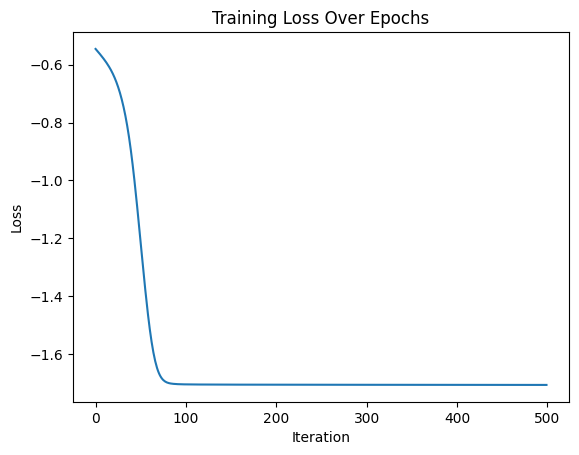

In [5]:
# 用cosine_similarity驱动的tangram进行计算
import cos_tg.train_tangram as tg_cos

# tangram
cos_sim_tg, _ = tg_cos.read_csv_and_run_tangram(
    [sc_1_],
    [st_1_],
    num_epochs=500,
    print_interval=500,
    lambda_g1=1,
    lambda_g2=1,
)

In [6]:
mapping = cos_sim_tg.argmax(axis=1)
print(mapping.shape)
sample_size = cos_sim_tg.shape[0]
print(sample_size)
gt = np.array(range(sample_size))
tg_cos_acc = np.sum(mapping == gt) / sample_size
print("tangram cosine accuracy:", tg_cos_acc)
mapping = cos_sim_tg.argmax(axis=1)
cos = cosine_similarity(sc_1_, st_1_)
cos_mapping = cos.argmax(axis=1)
cos_acc = np.sum(cos_mapping == gt) / sample_size
print("cosine accuracy:", cos_acc)

(4531,)
4531
tangram cosine accuracy: 1.0


cosine accuracy: 1.0


In [7]:
# tangram CCA 会出现nan
# import sim_tangram.train_tangram as tg_cca
# # tangram
# cca_tg_sim, _ = tg_cca.read_csv_and_run_tangram(
#     [gene_sc_tensor],
#     [gene_st_tensor],
#     num_epochs=500,
#     print_interval=1,
#     lambda_g1=1,
#     lambda_g2=1,
# )

In [8]:
# 对每一行应用softmax转换为概率分布
tg = torch.tensor(cos, dtype=torch.float32)
# 对每一行应用softmax得到概率分布
prob = torch.softmax(tg, dim=1)

# 获取每行的最大概率值
max_probs = prob.max(dim=1)[0]

# # 找到概率值前50%的索引
k = len(max_probs) // 2   # 取50%
# top_indices = torch.argsort(max_probs, descending=True)[:k]
top_indices = torch.arange(k)

# 获取这些高置信度的mapping
# confident_mappings = tg[top_indices].argmax(axis=1)
confident_mappings = top_indices

In [9]:
print(top_indices)
print(confident_mappings)
print(cos_sim_tg.shape)
print(confident_mappings.shape)
print(top_indices.shape)
# confident_mappings
# top_indices

tensor([   0,    1,    2,  ..., 2262, 2263, 2264])
tensor([   0,    1,    2,  ..., 2262, 2263, 2264])
(4531, 4531)
torch.Size([2265])
torch.Size([2265])


In [10]:

latent_dim = 100
sc1_conf = sc_1_[top_indices]
st1_conf = st_1_[confident_mappings]
st2_conf = st_2_[confident_mappings]
view_sc1_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(sc_1_)
view_st1_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(st_1_)
view_st2_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(st_2_)
view_sc1_conf_feature = view_sc1_feature[top_indices]
view_st1_conf_feature = view_st1_feature[confident_mappings]
view_st2_conf_feature = view_st2_feature[confident_mappings]
# view_sc1_conf_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(sc1_conf)
# view_st1_conf_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(st1_conf)
# view_st2_conf_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(st2_conf)
# view_sc1_label, _, _ = phenograph.cluster(view_sc1_conf_feature, random_state=42)
# view_st1_label, _, _ = phenograph.cluster(view_st1_conf_feature, random_state=42)
# view_st2_label, _, _ = phenograph.cluster(view_st2_conf_feature, random_state=42)
view_sc1_label, _, _ = phenograph.cluster(view_sc1_feature, random_state=42)
view_st1_label, _, _ = phenograph.cluster(view_st1_feature, random_state=42)
view_st2_label, _, _ = phenograph.cluster(view_st2_feature, random_state=42)
view_sc1_conf_label = view_sc1_label[top_indices]
view_st1_conf_label = view_st1_label[confident_mappings]
view_st2_conf_label = view_st2_label[confident_mappings]


Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.13231539726257324 seconds
Jaccard graph constructed in 0.4192230701446533 seconds
Wrote graph to binary file in 0.019724369049072266 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.786693
After 2 runs, maximum modularity is Q = 0.788184
Louvain completed 22 runs in 1.4833297729492188 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 2.39345121383667 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.09409809112548828 seconds
Jaccard graph constructed in 0.41280317306518555 seconds
Wrote graph to binary file in 0.020880460739135742 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.803095
Louvain completed 21 runs in 1.083641529083252 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 1.9349746704101562 sec

In [11]:
# # tangram
# cos_sim_tg, _ = tg_cos.read_csv_and_run_tangram(
#     # [sc_1],
#     # [st_1],
#     [view_sc1_feature],
#     [view_st1_feature],
#     num_epochs=500,
#     print_interval=500,
#     lambda_g1=1,
#     lambda_g2=1,
# )

In [12]:
mapping = cos_sim_tg.argmax(axis=1)
print(mapping.shape)
sample_size = cos_sim_tg.shape[0]
print(sample_size)
gt = np.array(range(sample_size))
tg_cos_acc = np.sum(mapping == gt) / sample_size
print("tangram cosine accuracy:", tg_cos_acc)
gt = np.array(range(sample_size))
mapping = cos_sim_tg.argmax(axis=1)
cos = cosine_similarity(sc_1_, st_1_)
cos_mapping = cos.argmax(axis=1)
cos_acc = np.sum(cos_mapping == gt) / sample_size
print("cosine accuracy:", cos_acc)

(4531,)
4531
tangram cosine accuracy: 1.0
cosine accuracy: 1.0


In [13]:
cos = cosine_similarity(sc_1_[top_indices], st_1_[confident_mappings])
cos_mapping = cos.argmax(axis=1)
print(cos_mapping.shape)
sample_size = cos.shape[0]
gt = np.array(range(sample_size))
cos_acc = np.sum(cos_mapping == gt) / sample_size
print("cosine accuracy:", cos_acc)

(2265,)
cosine accuracy: 1.0


In [14]:
print(sc1_conf.shape)
print(st1_conf.shape)
print(st2_conf.shape)
print(view_sc1_label.shape)
print(view_st1_label.shape)
print(view_st2_label.shape)

(2265, 23296)
(2265, 23296)
(2265, 23296)
(4531,)
(4531,)
(4531,)


In [62]:
import multi_muse_sc as muse

outputs = muse.dual_muse_fit_predict(
    [sc1_conf],
    [st1_conf, st2_conf],
    # [st1_conf],
    [view_sc1_conf_label],
    [view_st1_conf_label, view_st2_conf_label],
    # [view_st1_label],
    latent_dim=100,
    n_epochs=500,
    info_nce_lambda=10,
    weight_penalty=1,
    triplet_lambda=10,
    info_nce_lambda_st=0,
    reconstruct_lambda_sc=10,
    reconstruct_lambda_st=10,
)

++++++++++ DualMUSE for multi-modality single-cell analysis ++++++++++
#epoch: 0/200 	 total loss: 2226.43 	 sc loss: 887.98 	 st loss: 1205.25 	 infoNCE: 133.20 	 sc recon: 789.12 	 st recon: 1063.75 	 sc sparse: 98.86 	 st sparse: 141.50 	 sc trip: 0.00 	 st trip: 0.00 	 sc infoNCE: 0.00 	 st infoNCE: 0.00
#epoch: 25/200 	 total loss: 1805.76 	 sc loss: 755.79 	 st loss: 1035.53 	 infoNCE: 14.45 	 sc recon: 657.94 	 st recon: 895.46 	 sc sparse: 97.85 	 st sparse: 140.07 	 sc trip: 0.00 	 st trip: 0.00 	 sc infoNCE: 0.00 	 st infoNCE: 0.00
#epoch: 50/200 	 total loss: 1769.12 	 sc loss: 745.09 	 st loss: 1018.12 	 infoNCE: 5.91 	 sc recon: 648.51 	 st recon: 879.81 	 sc sparse: 96.57 	 st sparse: 138.32 	 sc trip: 0.00 	 st trip: 0.00 	 sc infoNCE: 0.00 	 st infoNCE: 0.00
#epoch: 75/200 	 total loss: 1756.26 	 sc loss: 739.46 	 st loss: 1012.07 	 infoNCE: 4.73 	 sc recon: 644.24 	 st recon: 875.65 	 sc sparse: 95.21 	 st sparse: 136.42 	 sc trip: 0.00 	 st trip: 0.00 	 sc infoNCE: 0.

In [63]:
model = outputs[6]

from multi_muse_sc import *

with torch.no_grad():
    data_inputs_tensor_sc = get_all_tensor(
        [sc_1_]
    )
    data_inputs_tensor_st = get_all_tensor(
        [st_1_, st_2_]
    )
    data_pca_tensor_sc = get_all_tensor(
        [view_sc1_feature]
    )
    out = model(
        # data_inputs_tensor_sc,
        data_inputs_tensor_sc,
        # data_pca_tensor_sc,
        # data_inputs_tensor_st,
        data_inputs_tensor_st,
        info_nce_lambda=0,
    )
    # out2 = model(
    #     data_inputs_tensor_st,
    #     data_inputs_tensor_sc,
    #     info_nce_lambda=0,
    # )

In [64]:
sc_gene_hat = out[1][0]
st_gene_hat = out[1][1]
latent_sc = out[0][0]
latent_st = out[0][1]
# latent_sc = sc_gene_hat[0]
# latent_st = st_gene_hat[0]
# latent_st = out2[0][0]
sc1_encode = out[2][0][0]
st1_encode = out[2][1][0]
st2_encode = out[2][1][1]


print(latent_sc.shape)
print(latent_st.shape)
print(sc1_encode.shape)

torch.Size([4531, 100])
torch.Size([4531, 100])
torch.Size([4531, 128])


In [65]:
# device = torch.device('cuda:0')
# latent_sc, latent_st = torch.from_numpy(outputs[0]), torch.from_numpy(outputs[1])
# latent_sc, latent_st = latent_sc.to(device), latent_st.to(device)

**************************************************
S: torch.Size([4531, 100, 1])
G: torch.Size([4531, 100, 1])


  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:01<00:00, 289.63it/s]

Epoch 500: Loss -1.6802589893341064
[[13.402125    1.9895443   3.2218964  ... -1.7798517   6.434651
  -2.3749416 ]
 [-0.63971245 13.117207    2.6789644  ... -1.683345   -0.75123626
  -1.5939298 ]
 [ 1.6723514   1.8554701  13.683621   ... -0.9510469  -0.41025016
  -1.6806265 ]
 ...
 [-0.34230027  0.2826975   0.49131402 ... -1.5998247  -0.76361144
  -2.1609323 ]
 [-0.5505983  -1.484334   -0.16784374 ... -1.723625   13.049819
   0.52479935]
 [-0.40511078 -2.7017345  -0.38205096 ... -2.017575    2.3228762
  13.246563  ]]


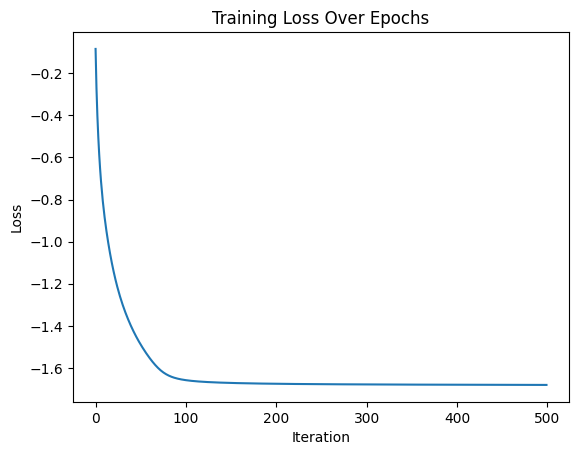

In [66]:
# tangram
cos_tg, _ = tg_cos.read_csv_and_run_tangram(
    [latent_sc],
    [latent_st],
    num_epochs=500,
    print_interval=500,
    lambda_g1=1,
    lambda_g2=1,
)

**************************************************
S: torch.Size([4531, 100, 1])
G: torch.Size([4531, 100, 1])


  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:02<00:00, 183.52it/s]

Epoch 500: Loss -1.3119535446166992
[[ 1.0105021e+01  8.4273517e-01  2.4727540e+00 ... -1.2046189e+00
   1.8106050e+00  6.7618363e-02]
 [-1.2086290e+00  9.1289711e+00  1.5809711e+00 ... -1.6152632e+00
   9.1855414e-02 -1.4319720e+00]
 [-1.1358521e+00 -1.3488920e+00  8.6322708e+00 ... -3.1791678e-01
   6.1194844e+00 -2.1041916e-01]
 ...
 [-1.5797925e+00 -2.4893387e-01 -9.5570097e-03 ... -2.0893338e+00
  -4.7251835e-01 -9.3506998e-01]
 [-1.9030086e+00 -1.1974732e+00 -9.0493923e-01 ... -1.7357026e+00
   8.3104496e+00  4.2940226e-01]
 [-3.4596954e-02 -2.8992593e+00 -1.4190016e+00 ... -1.1369352e+00
   3.8750139e-01  1.5986826e+00]]


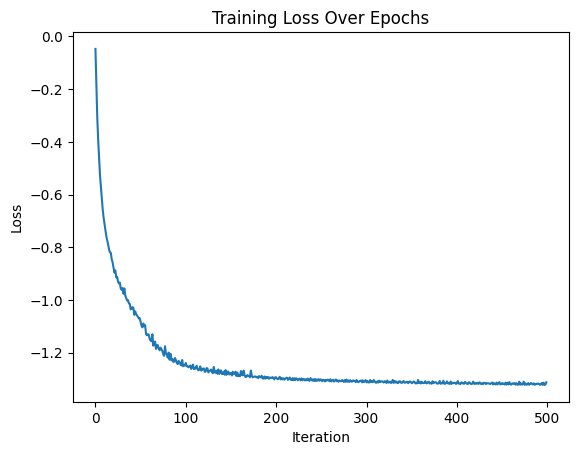

In [67]:
import sim_tangram.train_tangram as tg_cca

cca_tg, _ = tg_cca.read_csv_and_run_tangram(
    [latent_sc],
    [latent_st],
    num_epochs=500,
    print_interval=500,
    lambda_g1=1,
    lambda_g2=1,
)

In [68]:
# torch.save(torch.tensor(cos_tg, dtype=torch.float32), f'/home/lqr/CLIMA/code/pretrained_weights/{dataset}_conf_tg.pt')
# torch.save(torch.tensor(cca_tg, dtype=torch.float32), f'/home/lqr/CLIMA/code/pretrained_weights/{dataset}_conf_tg_cca_encode.pt')
# torch.save(torch.tensor(cos, dtype=torch.float32), f'/home/lqr/CLIMA/code/pretrained_weights/{dataset}_conf_cos.pt')

In [69]:
from scipy.special import softmax

sample_size = latent_sc.shape[0]
gt1 = np.array(range(k))
gt2 = np.array(range(k, sample_size))
print(f"k:{k}, sample_size:{sample_size}")

cos = cosine_similarity(latent_sc.cpu().numpy(), latent_st.cpu().numpy())
cos = np.log(softmax(cos, axis=1))+np.log(softmax(cos, axis=0))

# cos = cosine_similarity(sc_1_, sc_1_)
cos_mapping = cos.argmax(axis=1)
cos_acc = np.sum(cos_mapping[:k] == gt1) / k
cos_acc2 = np.sum(cos_mapping[k:] == gt2) / (sample_size - k)
print(f"cosine accuracy: {cos_acc:.2f}, {cos_acc2:.2f}")
cos_mapping = cos.argmax(axis=0)
cos_acc = np.sum(cos_mapping[:k] == gt1) / k
cos_acc2 = np.sum(cos_mapping[k:] == gt2) / (sample_size - k)
print(f"cosine accuracy: {cos_acc:.2f}, {cos_acc2:.2f}")
cos_tg_mapping = cos_tg.argmax(axis=1)
cos_tg_acc = np.sum(cos_tg_mapping[:k] == gt1) / k
cos_tg_acc2 = np.sum(cos_tg_mapping[k:] == gt2) / (sample_size - k)
print(f"tangram cosine accuracy: {cos_tg_acc:.2f}, {cos_tg_acc2:.2f}")
cca_mapping = cca_tg.argmax(axis=1)
cca_tg_acc = np.sum(cca_mapping[:k] == gt1) / k
cca_tg_acc2 = np.sum(cca_mapping[k:] == gt2) / (sample_size - k)
print(f"tangram cca accuracy: {cca_tg_acc:.2f}, {cca_tg_acc2:.2f}")

k:2265, sample_size:4531
cosine accuracy: 1.00, 0.74
cosine accuracy: 1.00, 0.90
tangram cosine accuracy: 1.00, 0.68
tangram cca accuracy: 0.79, 0.31


In [70]:
# 计算latent feature和original feature的聚类情况
latent_sc1_label, _, _ = phenograph.cluster(latent_sc.cpu().numpy(), random_state=42)
latent_st1_label, _, _ = phenograph.cluster(latent_st.cpu().numpy(), random_state=42)

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.09577560424804688 seconds
Jaccard graph constructed in 0.8162446022033691 seconds
Wrote graph to binary file in 0.02264237403869629 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.807968
After 2 runs, maximum modularity is Q = 0.809478
Louvain completed 22 runs in 1.8931703567504883 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 3.501281976699829 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.09728574752807617 seconds
Jaccard graph constructed in 0.8070054054260254 seconds
Wrote graph to binary file in 0.025440454483032227 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.569817
After 3 runs, maximum modularity is Q = 0.570891
Louvain completed 23 runs in 2.061262369155884 seconds
Sorting communities by size, please wait ..

In [71]:
encode_sc1_label, _, _ = phenograph.cluster(sc1_encode.cpu().numpy(), random_state=42)
encode_st1_label, _, _ = phenograph.cluster(st1_encode.cpu().numpy(), random_state=42)
encode_st2_label, _, _ = phenograph.cluster(st2_encode.cpu().numpy(), random_state=42)

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.10064959526062012 seconds
Jaccard graph constructed in 0.9387099742889404 seconds
Wrote graph to binary file in 0.02443695068359375 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.74254
After 10 runs, maximum modularity is Q = 0.743688
Louvain completed 30 runs in 2.481152057647705 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 4.26530385017395 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.1068267822265625 seconds
Jaccard graph constructed in 0.788170576095581 seconds
Wrote graph to binary file in 0.025821685791015625 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.568617
After 4 runs, maximum modularity is Q = 0.572219
After 6 runs, maximum modularity is Q = 0.573455
Louvain completed 26 runs in 2.5779168605804443 secon

In [72]:
from sklearn.metrics import adjusted_rand_score as ari

def print_ari(title, ari_values):
    print('*' * 10)
    print(title)
    for description, value in ari_values:
        print(f"{description} ari: {value:.2f}")

In [ ]:
# fuse_sc = latent_sc1_label
# fuse_st = latent_st1_label
# encode_sc = encode_sc1_label
# encode_st = encode_st1_label
# org_sc = view_sc1_label
# org_st = view_st1_label

# print_ari("org vs org", [("sc vs st", ari(org_sc, org_st))])

# print_ari("org vs fuse", [("sc vs sc front", ari(org_sc[:k], fuse_sc[:k])), ("st vs st front", ari(org_st[:k], fuse_st[:k])), ("sc vs sc rear", ari(org_sc[k:], fuse_sc[k:])), ("st vs st rear", ari(org_st[k:], fuse_st[k:]))])

# print_ari("org vs encode", [("sc vs sc front", ari(org_sc[:k], encode_sc[:k])), ("st vs st front", ari(org_st[:k], encode_st[:k])), ("sc vs sc rear", ari(org_sc[k:], encode_sc[k:])), ("st vs st rear", ari(org_st[k:], encode_st[k:]))])

# print_ari("fuse vs encode", [("sc vs sc front", ari(fuse_sc[:k], encode_sc[:k])), ("st vs st front", ari(fuse_st[:k], encode_st[:k])), ("sc vs sc rear", ari(fuse_sc[k:], encode_sc[k:])), ("st vs st rear", ari(fuse_st[k:], encode_st[k:]))])


**********
org vs org
sc vs st ari: 0.45
**********
org vs fuse
sc vs sc front ari: 0.94
st vs st front ari: 0.99
sc vs sc rear ari: 0.37
st vs st rear ari: 0.27
**********
org vs encode
sc vs sc front ari: 0.92
st vs st front ari: 0.99
sc vs sc rear ari: 0.43
st vs st rear ari: 0.31
**********
fuse vs encode
sc vs sc front ari: 0.98
st vs st front ari: 1.00
sc vs sc rear ari: 0.61
st vs st rear ari: 0.65


In [73]:
fuse_sc = latent_sc1_label
fuse_st = latent_st1_label
encode_sc = encode_sc1_label
encode_st = encode_st1_label
encode_st2 = encode_st2_label
org_sc = view_sc1_label
org_st = view_st1_label
org_st2 = view_st2_label

print_ari("org vs org", [("sc vs st", ari(org_sc, org_st)), ("sc vs st2", ari(org_sc, org_st2)), ("st vs st2", ari(org_st, org_st2))])

print_ari("org vs fuse", [("sc vs sc front", ari(org_sc[:k], fuse_sc[:k])), ("st vs st front", ari(org_st[:k], fuse_st[:k])), ("st2 vs st front", ari(org_st2[:k], fuse_st[:k])), ("sc vs sc rear", ari(org_sc[k:], fuse_sc[k:])), ("st vs st rear", ari(org_st[k:], fuse_st[k:])), ("st2 vs st rear", ari(org_st2[k:], fuse_st[k:]))])

print_ari("org vs encode", [("sc vs sc front", ari(org_sc[:k], encode_sc[:k])), ("st vs st front", ari(org_st[:k], encode_st[:k])), ("st2 vs st2 front", ari(org_st2[:k], encode_st2[:k])), ("sc vs sc rear", ari(org_sc[k:], encode_sc[k:])), ("st vs st rear", ari(org_st[k:], encode_st[k:])), ("st2 vs st2 rear", ari(org_st2[k:], encode_st2[k:]))])

print_ari("fuse vs encode", [("sc vs sc front", ari(fuse_sc[:k], encode_sc[:k])), ("st vs st front", ari(fuse_st[:k], encode_st[:k])), ("st vs st2 front", ari(fuse_st[:k], encode_st2[:k])), ("sc vs sc rear", ari(fuse_sc[k:], encode_sc[k:])), ("st vs st rear", ari(fuse_st[k:], encode_st[k:])), ("st vs st2 rear", ari(fuse_st[k:], encode_st2[k:]))])


**********
org vs org
sc vs st ari: 0.45
sc vs st2 ari: 0.29
st vs st2 ari: 0.15
**********
org vs fuse
sc vs sc front ari: 0.94
st vs st front ari: 0.36
st2 vs st front ari: 0.35
sc vs sc rear ari: 0.40
st vs st rear ari: 0.25
st2 vs st rear ari: 0.29
**********
org vs encode
sc vs sc front ari: 0.92
st vs st front ari: 0.36
st2 vs st2 front ari: 0.45
sc vs sc rear ari: 0.46
st vs st rear ari: 0.25
st2 vs st2 rear ari: 0.40
**********
fuse vs encode
sc vs sc front ari: 0.98
st vs st front ari: 0.36
st vs st2 front ari: 0.38
sc vs sc rear ari: 0.70
st vs st rear ari: 0.27
st vs st2 rear ari: 0.34
